# Dark photon lifetime -- acceptance-corrected c$\tau$

`lifetime_validation.ipynb` shows the measured proper c$\tau$ falls below nominal for long lifetimes.
This notebook recovers the **intrinsic** c$\tau$ across the whole grid by modelling the truncation.

## The model

The generator keeps a dark photon only if it decays within a maximum **lab-frame** distance $R_{\max}$.
The lab decay length is the proper length boosted, $L_{\rm lab}=x\,\beta\gamma$, so a DP with proper
decay length $x$ survives iff $\beta\gamma < R_{\max}/x$. The observed proper-decay-length distribution
is therefore the true exponential **times an acceptance** $\varepsilon(x)$:

$$\mathrm{observed}(x)=\frac{1}{c\tau}e^{-x/c\tau}\,\varepsilon(x),\qquad
\varepsilon(x)=P(\beta\gamma<R_{\max}/x)=F_{\beta\gamma}(R_{\max}/x).$$

We fit $\log(dN/dx)=\log A - x/c\tau + \log\varepsilon(x;R_{\max})$ for $(A, c\tau, R_{\max})$.

**Key assumption:** $F_{\beta\gamma}$ is the **true** (un-truncated) boost distribution. A long-lifetime
sample's own $\beta\gamma$ is biased low (high-$\beta\gamma$ DPs are exactly the ones cut), but $\beta\gamma$
depends only on production kinematics (the masses), **not** lifetime -- so we take $F_{\beta\gamma}$ from
the **shortest-c$\tau$ (faithful) sample of the same mass point**.

$R_{\max}$ is a single generator decay-volume constant, so a strong cross-check is that the fitted
$R_{\max}$ agrees across mass points.

## Caveats
- Assumes the only truncation is a sharp lab-decay-length cap (no $\eta$ / non-spherical-volume effects).
- Assumes the underlying distribution is a clean exponential (validated by the log-linear core).
- Run on `baseNoLj_noTrigger` so the HLT trigger does not sculpt the gen distribution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import lifetime_analysis as la
from sidm.tools import utilities
utilities.set_plot_style()
%matplotlib inline

In [2]:
# Load the full v10 grid (xrdcp'd from lpcmetx EOS if not cached locally) and
# compute the three ctau estimators per sample (mean / core-slope / acceptance-corrected).
output = la.load_grid()
rows, groups, bg_mean = la.compute_grid(output)
print(f"{len(groups)} mass points, {len(rows)} samples, "
      f"<betagamma> in [{min(bg_mean.values()):.0f}, {max(bg_mean.values()):.0f}]")
faithful = [rows[s]['mean']/rows[s]['nominal'] for s in rows if rows[s]['nominal'] <= 1]
print(f"faithful regime (ctau <= 1 cm): median measured/nominal = {np.median(faithful):.3f}  (N={len(faithful)})")

/uscms_data/d3/murtazas/SIDM/sidm/studies/lifetime_study/lifetime_analysis.py:53: RuntimeWarning: invalid value encountered in divide
  effN = np.where(var > 0, vals**2 / var, 0.0)
/uscms_data/d3/murtazas/SIDM/sidm/studies/lifetime_study/lifetime_analysis.py:70: RuntimeWarning: divide by zero encountered in divide
  sig = np.where(effN > 0, 1 / np.sqrt(effN), np.inf)


36 mass points, 179 samples, <betagamma> in [16, 2735]
faithful regime (ctau <= 1 cm): median measured/nominal = 0.994  (N=129)


## Method illustration: one mass point

Data $dN/dx$ (grey) with the acceptance-corrected model $e^{-x/c\tau}\,\varepsilon(x)$ overlaid (red).
The model bends over at high x to follow the truncation, so the fitted c$\tau$ is the **intrinsic**
value, not the truncated mean.

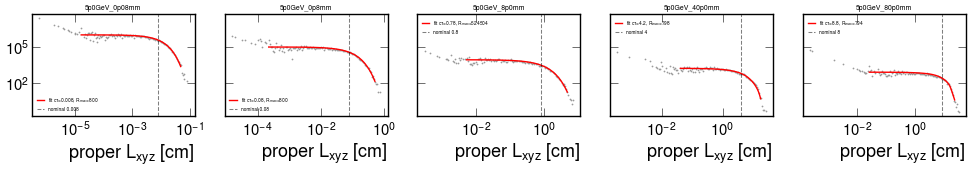

In [3]:
mp = ('4Mu', '500GeV', '5p0GeV')
samples = groups[mp]
F_bg, _ = la.betagamma_cdf(output, samples[0])
fig, axes = plt.subplots(1, len(samples), figsize=(4*len(samples), 4), sharey=True)
for ax, s in zip(np.atleast_1d(axes), samples):
    c, dens, effN, mean = la.proper_density(output, s)
    ctC, Rmax = la.acceptance_fit(output, s, F_bg, mean)
    nm = la.ctau_cm(s); g = effN >= 5
    eps = np.clip(F_bg(Rmax/c), 1e-12, 1)
    model = np.exp(-c/ctC) * eps
    norm = np.nansum(dens[g]) / np.nansum(model[g])
    ax.plot(c, dens, '.', ms=3, color='0.6')
    ax.plot(c[g], (norm*model)[g], 'r-', lw=2, label=fr'fit c$\tau$={ctC:.2g}, $R_{{\max}}$={Rmax:.0f}')
    ax.axvline(nm, color='k', ls='--', alpha=.5, label=f'nominal {nm:g}')
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_title(s.split('_',2)[-1], fontsize=10)
    ax.set_xlabel(r'proper $L_{xyz}$ [cm]'); ax.legend(fontsize=7)
fig.tight_layout()

## Full-grid results

**(1)** Measured/nominal vs nominal c$\tau$, per mass point coloured by $\langle\beta\gamma\rangle$:
the mean (top) droops with a boost-ordered onset; **the acceptance correction (bottom) flattens the whole grid to ~1**.

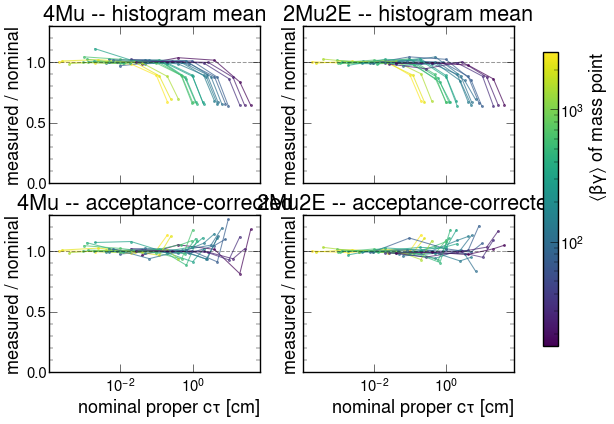

In [4]:
norm = mcolors.LogNorm(min(bg_mean.values()), max(bg_mean.values()))
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True, sharey=True)
for j, ch in enumerate(['4Mu', '2Mu2E']):
    for r, est in enumerate(['mean', 'optionC']):
        ax = axes[r][j]
        for k, ss in groups.items():
            if k[0] != ch: continue
            nom = [rows[s]['nominal'] for s in ss]
            val = [rows[s][est]/rows[s]['nominal'] for s in ss]
            ax.plot(nom, val, '-o', ms=3, color=cm.viridis(norm(bg_mean[k])), alpha=.7)
        ax.axhline(1, color='k', ls='--', alpha=.4); ax.set_xscale('log'); ax.set_ylim(0, 1.3)
        ax.set_title(f"{ch} -- {'histogram mean' if est=='mean' else 'acceptance-corrected'}")
        ax.set_ylabel('measured / nominal')
        if r == 1: ax.set_xlabel(r'nominal proper c$\tau$ [cm]')
sm = cm.ScalarMappable(norm=norm, cmap='viridis'); sm.set_array([])
fig.colorbar(sm, ax=axes, label=r'$\langle\beta\gamma\rangle$ of mass point', shrink=.85)

**(2)** The fitted $R_{\max}$ (from heavily-truncated samples, where it is well constrained) is one
flat band, and **(3)** the truncation onset tracks $R_{\max}/\langle\beta\gamma\rangle$ -- both confirm a
single generator decay-volume cut governs the whole grid.

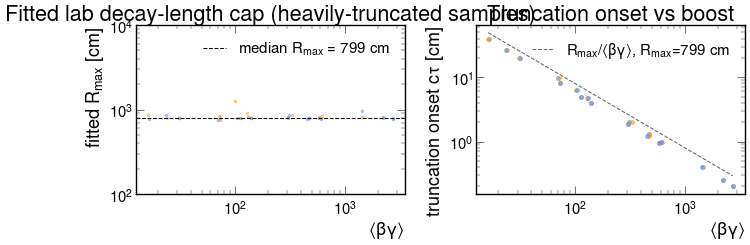

In [5]:
fig, (axR, axO) = plt.subplots(1, 2, figsize=(14, 5.5))

# (2) Rmax band: heavily-truncated samples only (mean/nominal < 0.7 => Rmax well constrained)
Rvals = []
for k, ss in groups.items():
    for s in ss:
        r = rows[s]
        if np.isfinite(r['Rmax']) and r['mean']/r['nominal'] < 0.7:
            axR.plot(bg_mean[k], r['Rmax'], 'o', ms=4, alpha=.5,
                     color='C0' if k[0]=='4Mu' else 'C1'); Rvals.append(r['Rmax'])
Rmed = np.median(Rvals)
axR.axhline(Rmed, color='k', ls='--', label=fr'median $R_{{\max}}$ = {Rmed:.0f} cm')
axR.set_xscale('log'); axR.set_yscale('log'); axR.set_ylim(1e2, 1e4)
axR.set_xlabel(r'$\langle\beta\gamma\rangle$'); axR.set_ylabel(r'fitted $R_{\max}$ [cm]')
axR.set_title('Fitted lab decay-length cap (heavily-truncated samples)'); axR.legend()

# (3) onset vs boost
for k, ss in groups.items():
    onset = next((rows[s]['nominal'] for s in ss if rows[s]['mean']/rows[s]['nominal'] < 0.8), None)
    if onset: axO.plot(bg_mean[k], onset, 'o', ms=6, alpha=.6, color='C0' if k[0]=='4Mu' else 'C1')
bg = np.array(sorted(bg_mean.values()))
axO.plot(bg, Rmed/bg, 'k--', alpha=.6, label=fr'$R_{{\max}}/\langle\beta\gamma\rangle$, $R_{{\max}}$={Rmed:.0f} cm')
axO.set_xscale('log'); axO.set_yscale('log')
axO.set_xlabel(r'$\langle\beta\gamma\rangle$'); axO.set_ylabel(r'truncation onset c$\tau$ [cm]')
axO.set_title('Truncation onset vs boost'); axO.legend()
fig.tight_layout()

## Result

- The acceptance-corrected fit pulls the long-lifetime points back onto $y=x$ across the whole grid,
  in both channels -- the samples are **truncated but faithful**, and the intrinsic c$\tau$ is recoverable.
- The fitted $R_{\max}$ is consistent (~one band) and the truncation onset follows
  $R_{\max}/\langle\beta\gamma\rangle$ over two decades of boost: a single generator decay-volume cut.
- This is what is needed to **use** the long-lifetime samples for a lifetime measurement or
  lifetime-reweighting, including for the Run-3 samples (point `la.load_grid` at their coffea).